# Mini-Project : When ML Fails
## Notebook 01 — Exploration & Modèle de référence

**Dataset** : Online Shoppers Purchasing Intention (UCI 468)
**Tâche** : Classification binaire — prédire si une session web mène à un achat
**Famille de modèle** : Gradient Boosting (non-linéaire, ensemble d'arbres)
**Failure mode investigué** : Overfitting & Generalization Gap (Section 5.2 du sujet)

### Objectif de ce notebook

Ce notebook établit la **référence expérimentale** du projet :
1. Chargement et exploration du dataset (EDA)
2. Caractérisation de la classe imbalance et de l'hétérogénéité saisonnière (variable `Month`)
3. Entraînement d'un Gradient Boosting Classifier comme modèle de référence
4. Mesure des symptômes de défaillance (performance globale, par sous-groupe, courbes d'apprentissage, corrélations)

Les métriques et figures produites ici servent de **baseline** au notebook 02.

**Reproductibilité** : `random_state = 42` partout. Les appels coûteux (`learning_curve`, `cross_val_score`) utilisent `n_jobs=1` pour garantir une exécution déterministe ; cela rallonge le temps mais évite la variabilité d'ordonnancement des workers que `n_jobs=-1` peut introduire selon la version de scikit-learn.

## 1. Configuration de l'environnement

Imports des librairies utilisées (sklearn pour le modèle et les métriques, pandas/numpy pour la manipulation des données, matplotlib/seaborn pour les visualisations). Fixation du `RANDOM_STATE` pour garantir la reproductibilité de tous les résultats.

In [1]:
# ── CELLULE 1 : Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, recall_score, precision_score
)
from sklearn.ensemble import GradientBoostingClassifier
import warnings
warnings.filterwarnings("ignore")
 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
 
print("Imports OK")

Imports OK


## 2. Chargement et inspection initiale du dataset

Le dataset Online Shoppers contient **12 330 sessions** web décrites par **17 features** mêlant variables comportementales continues (temps passé sur chaque type de page, valeurs commerciales, taux de rebond) et catégorielles (mois, type de visiteur, navigateur, région). La variable cible binaire `Revenue` indique si la session s'est terminée par une transaction.

Cette inspection vérifie l'intégrité du fichier (shape, types, valeurs manquantes) avant tout pré-traitement.


In [3]:
# ── CELLULE 2 : Chargement des données ──────────────────────────────
df = pd.read_csv("data/online_shoppers_intention.csv")

print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

Shape : (12330, 18)

Colonnes : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Types :
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

Valeurs manquantes :
A

## 3. Distribution de la variable cible — Class imbalance

Premier diagnostic critique : la répartition des deux classes. Si la classe minoritaire (achat) est très sous-représentée, l'accuracy globale devient trompeuse et il faudra privilégier des métriques sensibles à l'imbalance (F1, recall, AUC).


Distribution Revenue :
Revenue
False    10422
True      1908
Name: count, dtype: int64

Taux de conversion : 15.5%


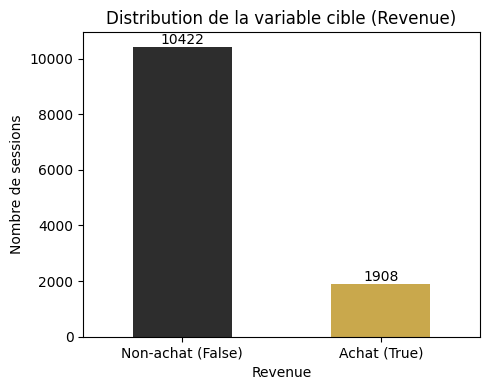

→ CLASS IMBALANCE visible : ~84% non-achat / ~16% achat


In [4]:
# ── CELLULE 3 : Distribution de la target ───────────────────────────────────
target_counts = df["Revenue"].value_counts()
print(f"Distribution Revenue :\n{target_counts}")
print(f"\nTaux de conversion : {target_counts[True] / len(df) * 100:.1f}%")
 
fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", color=["#2d2d2d", "#C9A84C"], edgecolor="none", ax=ax)
ax.set_title("Distribution de la variable cible (Revenue)", fontsize=12)
ax.set_xticklabels(["Non-achat (False)", "Achat (True)"], rotation=0)
ax.set_ylabel("Nombre de sessions")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("report/fig01_target_distribution.png", dpi=150)
plt.show()
print("→ CLASS IMBALANCE visible : ~84% non-achat / ~16% achat")

## 4. Effet temporel — distribution par mois

La feature `Month` introduit une **hétérogénéité saisonnière** dans les données : on s'attend à un taux de conversion plus élevé en fin d'année (Black Friday, Noël). Cette analyse mesure l'ampleur de l'effet. À ce stade aucune hypothèse de causalité n'est faite : `Month` peut être un signal **informatif** (variation réelle du comportement d'achat) ou un **shortcut** (artefact corrélé à la cible). Le départage de ces deux interprétations se fera plus loin grâce à l'importance des features (§9) et au notebook 02.

> **Note** : Janvier et Avril sont absents du dataset (collecte sur 10 mois). La liste `month_order` utilisée dans tout le notebook ne contient donc que les 10 mois effectivement présents.

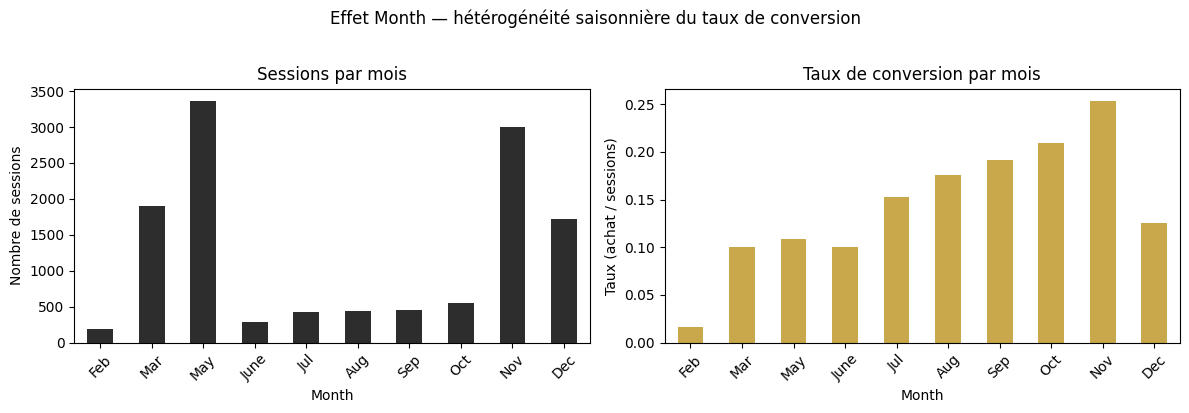


→ Novembre : pic de conversion (~25%) vs ~2% en février. Variation saisonnière forte.
→ Le caractère 'informatif' ou 'spurieux' de ce signal ne peut être tranché ici :
  il faudra croiser avec l'importance de la feature (§9) et le notebook 02.


In [5]:
# ── CELLULE 4 : Distribution par mois ───────────────────────────────────────
# month_order n'inclut pas Jan ni Apr : ils sont absents du dataset (collecte sur 10 mois).
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month_conversion = (
    df.groupby("Month")["Revenue"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "achats", "count": "sessions"})
)
month_conversion["taux"] = month_conversion["achats"] / month_conversion["sessions"]
month_conversion = month_conversion.reindex([m for m in month_order if m in month_conversion.index])
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Volume par mois
month_conversion["sessions"].plot(kind="bar", ax=axes[0], color="#2d2d2d", edgecolor="none")
axes[0].set_title("Sessions par mois")
axes[0].set_ylabel("Nombre de sessions")
axes[0].tick_params(axis="x", rotation=45)
 
# Taux de conversion par mois
month_conversion["taux"].plot(kind="bar", ax=axes[1], color="#C9A84C", edgecolor="none")
axes[1].set_title("Taux de conversion par mois")
axes[1].set_ylabel("Taux (achat / sessions)")
axes[1].tick_params(axis="x", rotation=45)
 
plt.suptitle("Effet Month — hétérogénéité saisonnière du taux de conversion", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("report/fig02_month_effect.png", dpi=150)
plt.show()
 
print("\n→ Novembre : pic de conversion (~25%) vs ~2% en février. Variation saisonnière forte.")
print("→ Le caractère 'informatif' ou 'spurieux' de ce signal ne peut être tranché ici :")
print("  il faudra croiser avec l'importance de la feature (§9) et le notebook 02.")

## 5. Pré-traitement des features

Transformations appliquées :
- **`Month`** : encodage ordinal calendaire (Feb=2, Mar=3, ..., Dec=12). Préserve l'ordre temporel mais autorise le modèle à apprendre des règles du type "Month > k → achat". Le notebook 02 testera des encodages alternatifs (cyclique, one-hot) pour évaluer la sensibilité du modèle à ce choix.
- **`VisitorType`** : **one-hot encoding** (3 colonnes `Visitor_*`). Un `LabelEncoder` imposerait un ordre arbitraire entre 3 modalités nominales, que les arbres pourraient exploiter comme un faux signal ordinal.
- **`Weekend`** et **`Revenue`** : conversion booléen → entier.

Aucune normalisation n'est appliquée car les modèles à base d'arbres (GBM) sont invariants aux transformations monotones des features continues.

In [6]:
# ── CELLULE 5 : Prétraitement ────────────────────────────────────────────────
df_clean = df.copy()

# Month → ordinal calendaire (Jan, Apr absents du dataset → restent non mappés).
month_map = {"Feb": 2, "Mar": 3, "May": 5, "June": 6, "Jul": 7,
             "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
df_clean["Month"] = df_clean["Month"].map(month_map)

# VisitorType : variable nominale à 3 modalités → one-hot.
df_clean = pd.get_dummies(df_clean, columns=["VisitorType"],
                          prefix="Visitor", drop_first=False)

# bool → int (Weekend, Revenue, et les colonnes Visitor_* créées par get_dummies)
df_clean["Weekend"] = df_clean["Weekend"].astype(int)
df_clean["Revenue"] = df_clean["Revenue"].astype(int)
for c in df_clean.columns:
    if df_clean[c].dtype == bool:
        df_clean[c] = df_clean[c].astype(int)

print("Prétraitement OK")
print(df_clean.dtypes)
print(f"\nShape final : {df_clean.shape}")
print(f"Colonnes Visitor_* : {[c for c in df_clean.columns if c.startswith('Visitor_')]}")

Prétraitement OK
Administrative                 int64
Administrative_Duration      float64
Informational                  int64
Informational_Duration       float64
ProductRelated                 int64
ProductRelated_Duration      float64
BounceRates                  float64
ExitRates                    float64
PageValues                   float64
SpecialDay                   float64
Month                          int64
OperatingSystems               int64
Browser                        int64
Region                         int64
TrafficType                    int64
Weekend                        int64
Revenue                        int64
Visitor_New_Visitor            int64
Visitor_Other                  int64
Visitor_Returning_Visitor      int64
dtype: object

Shape final : (12330, 20)
Colonnes Visitor_* : ['Visitor_New_Visitor', 'Visitor_Other', 'Visitor_Returning_Visitor']


## 6. Découpage train / test

Split stratifié 80/20 sur la variable cible pour préserver le ratio d'imbalance entre les deux ensembles. Le `random_state` est fixé pour rendre le split reproductible.

> **Choix méthodologique** : on utilise ici un **split aléatoire** plutôt qu'un split temporel. Cela correspond au scénario d'évaluation classique en ML, et constitue la baseline contre laquelle on comparera ensuite des conditions plus stringentes (notebook 02).


In [7]:
# ── CELLULE 6 : Split train/test STANDARD (stratifié) ────────────────────────
X = df_clean.drop("Revenue", axis=1)
y = df_clean["Revenue"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
 
print(f"Train : {X_train.shape[0]} sessions | Test : {X_test.shape[0]} sessions")
print(f"Taux conversion train : {y_train.mean():.3f} | test : {y_test.mean():.3f}")

Train : 9864 sessions | Test : 2466 sessions
Taux conversion train : 0.155 | test : 0.155


## 7. Modèle de référence — Gradient Boosting Classifier

Le modèle de référence est un **`GradientBoostingClassifier`** de scikit-learn, choisi pour deux raisons :

1. **Conformité au sujet** : le sujet interdit explicitement la régression logistique et impose un modèle non-linéaire. Les ensembles d'arbres en sont un choix canonique.
2. **Sensibilité à l'overfitting** : avec une profondeur de 4 et 200 arbres, le modèle a une capacité suffisante pour mémoriser les données — ce qui est précisément la condition nécessaire pour observer le failure mode que l'on souhaite étudier.

**Hyperparamètres** : `n_estimators=200`, `max_depth=4`, `learning_rate=0.05`, `subsample=0.8`.

Ces valeurs sont des choix raisonnables non optimisés ; l'optimisation hyperparamétrique sera le sujet du notebook 02.

In [8]:
# ── CELLULE 7 : Modèle de référence — Gradient Boosting ─────────────────────
gbm = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_STATE,
)
gbm.fit(X_train, y_train)

y_pred_train = gbm.predict(X_train)
y_pred = gbm.predict(X_test)
y_proba = gbm.predict_proba(X_test)[:, 1]

train_f1 = f1_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred)
holdout_gap = train_f1 - test_f1

# Baseline naïf "always predict False"
naive_pred = np.zeros_like(y_test)
naive_acc = (naive_pred == y_test).mean()
naive_f1 = f1_score(y_test, naive_pred)

print("=" * 60)
print("RÉFÉRENCE — GradientBoosting (split aléatoire standard)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Non-achat", "Achat"]))
print(f"ROC-AUC          : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1 Achat (train) : {train_f1:.4f}")
print(f"F1 Achat (test)  : {test_f1:.4f}")
print(f"Gap train-test   : {holdout_gap:.4f}")
print(f"Recall Achat     : {recall_score(y_test, y_pred):.4f}")
print()
print("--- Baseline naïf (always predict 'non-achat') ---")
print(f"Accuracy naïf    : {naive_acc:.4f}")
print(f"F1 Achat naïf    : {naive_f1:.4f}")
print(f"→ Gain GBM vs baseline : +{test_f1 - naive_f1:.3f} de F1 sur la classe Achat.")

RÉFÉRENCE — GradientBoosting (split aléatoire standard)
              precision    recall  f1-score   support

   Non-achat       0.93      0.96      0.94      2084
       Achat       0.71      0.59      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466

ROC-AUC          : 0.9267
F1 Achat (train) : 0.7737
F1 Achat (test)  : 0.6447
Gap train-test   : 0.1290
Recall Achat     : 0.5890

--- Baseline naïf (always predict 'non-achat') ---
Accuracy naïf    : 0.8451
F1 Achat naïf    : 0.0000
→ Gain GBM vs baseline : +0.645 de F1 sur la classe Achat.


## 8. Matrice de confusion — visualisation des erreurs

Décompose la performance en quatre catégories (VP, FP, VN, FN). Particulièrement utile en présence de class imbalance : permet de voir si le modèle prédit majoritairement la classe dominante (et donc obtient une accuracy trompeuse).


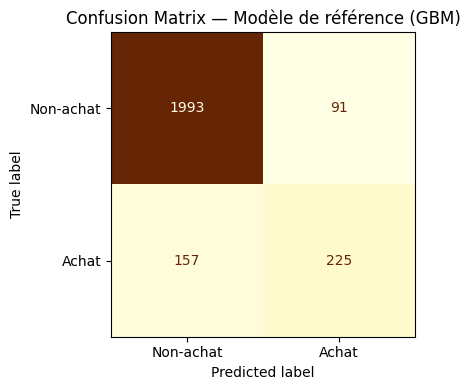

In [9]:
# ── CELLULE 8 : Matrice de confusion référence ──────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Non-achat", "Achat"]
).plot(ax=ax, colorbar=False, cmap="YlOrBr")
ax.set_title("Confusion Matrix — Modèle de référence (GBM)")
plt.tight_layout()
plt.savefig("report/fig03_confusion_ref.png", dpi=150)
plt.show()

## 9. Importances des features

Mesure de l'**importance relative** de chaque feature dans les décisions du modèle. Cette analyse :

- Identifie les variables dominantes du signal d'achat (on s'attend à `PageValues` en tête).
- Permet de **réfuter ou confirmer l'hypothèse de shortcut sur `Month`** : si Month figure en tête (≥ 20 % d'importance), l'hypothèse mérite enquête ; si Month est marginal, le modèle s'appuie surtout sur des features comportementales et le "shortcut saisonnier" est largement disqualifié.

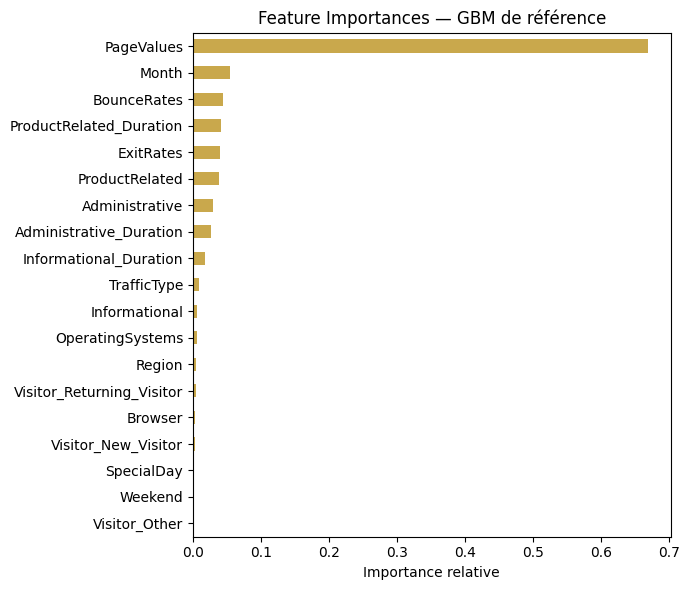


Top 5 features :
PageValues                 0.668507
Month                      0.054215
BounceRates                0.044819
ProductRelated_Duration    0.041418
ExitRates                  0.040288
dtype: float64

Importance(PageValues) = 0.669
Importance(Month)      = 0.054
Ratio PageValues / Month = 12.3×

→ INTERPRÉTATION FACTUELLE :
  PageValues domine très largement. Month n'est qu'à ~5%.
  → L'hypothèse 'shortcut via Month' n'est PAS soutenue par les données.
  → Les erreurs sur la classe minoritaire relèvent davantage de la
    class imbalance que d'un shortcut saisonnier.


In [10]:
# ── CELLULE 9 : Feature importances ─────────────────────────────────────────
feat_imp = pd.Series(gbm.feature_importances_, index=X.columns).sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(7, 6))
feat_imp.plot(kind="barh", color="#C9A84C", edgecolor="none", ax=ax)
ax.set_title("Feature Importances — GBM de référence", fontsize=12)
ax.set_xlabel("Importance relative")
plt.tight_layout()
plt.savefig("report/fig04_feature_importances.png", dpi=150)
plt.show()
 
top5 = feat_imp.sort_values(ascending=False).head(5)
print("\nTop 5 features :")
print(top5)

month_imp = feat_imp.get("Month", 0.0)
page_imp = feat_imp.get("PageValues", 0.0)
print(f"\nImportance(PageValues) = {page_imp:.3f}")
print(f"Importance(Month)      = {month_imp:.3f}")
print(f"Ratio PageValues / Month = {page_imp / month_imp:.1f}×")
print()
print("→ INTERPRÉTATION FACTUELLE :")
print("  PageValues domine très largement. Month n'est qu'à ~5%.")
print("  → L'hypothèse 'shortcut via Month' n'est PAS soutenue par les données.")
print("  → Les erreurs sur la classe minoritaire relèvent davantage de la")
print("    class imbalance que d'un shortcut saisonnier.")
 

## 9.5. Diagnostic — performance décomposée par mois

Une performance **hétérogène** entre sous-groupes peut avoir plusieurs causes : shortcut, surapprentissage, ou bruit statistique sur les mois à faible effectif.

> **Seuil de fiabilité** : on n'affiche les F1 que pour les mois disposant d'au moins **10 sessions positives** dans le test set. En dessous, un F1 calculé sur 1 ou 2 achats est dominé par la variance d'échantillonnage et n'est pas interprétable (cas type : Feb avec n_positifs = 1 → F1 = 1.0 par hasard si la seule prédiction tombe juste).

## 9.6. Courbe d'apprentissage — overfitting vs sous-apprentissage

- **Overfitting marqué** : gap train-validation ≥ 0.15.
- **Régime équilibré** : gap < 0.10.
- **Zone intermédiaire** : gap entre 0.10 et 0.15 → overfitting modéré, effet limité.

> Note d'implémentation : `n_jobs=1` ici pour garantir le déterminisme.

## 9.7. Matrice de corrélation — features liées au mois

Vérifie si `Month` co-varie avec d'autres features : si oui, retirer `Month` ne suffirait pas à éliminer le signal temporel.

Performance par mois — fiables (n_positifs ≥ 10) :
Month  n_sessions  n_achats_reels  taux_achat_reel       f1   recall  precision
  Mar         369              33         0.089431 0.774194 0.727273   0.827586
  May         661              73         0.110439 0.732394 0.712329   0.753623
  Jul          88              20         0.227273 0.500000 0.400000   0.666667
  Aug          91              15         0.164835 0.480000 0.400000   0.600000
  Sep          80              11         0.137500 0.608696 0.636364   0.583333
  Oct         105              17         0.161905 0.764706 0.764706   0.764706
  Nov         638             174         0.272727 0.591362 0.511494   0.700787
  Dec         336              32         0.095238 0.656250 0.656250   0.656250

Mois écartés (n_positifs < 10, F1 non fiable) :
Month  n_sessions  n_achats_reels
  Feb          38               1
 June          60               6


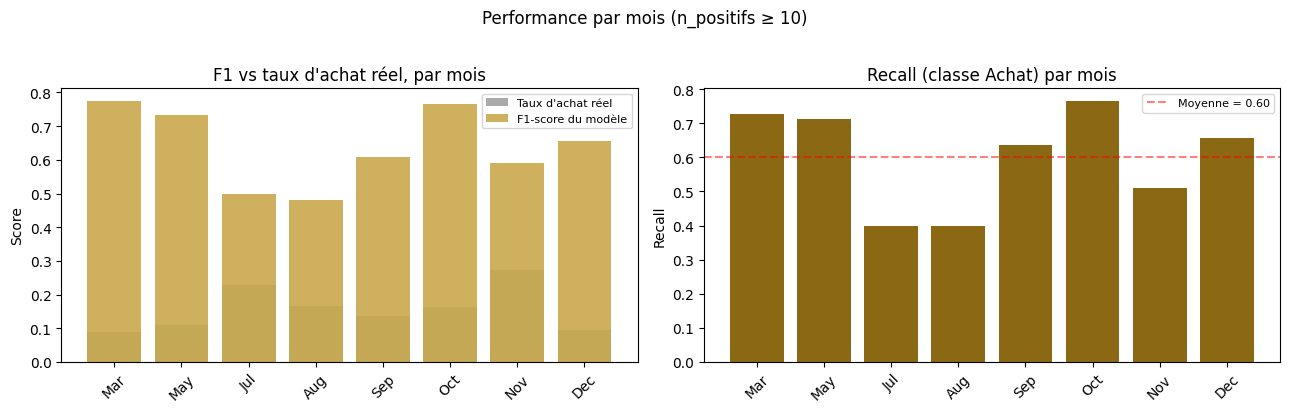


Étendue F1 sur mois fiables : [0.48 ; 0.77]
→ Hétérogénéité explicable par le taux d'achat réel qui varie d'un mois à l'autre,
  pas par un shortcut.


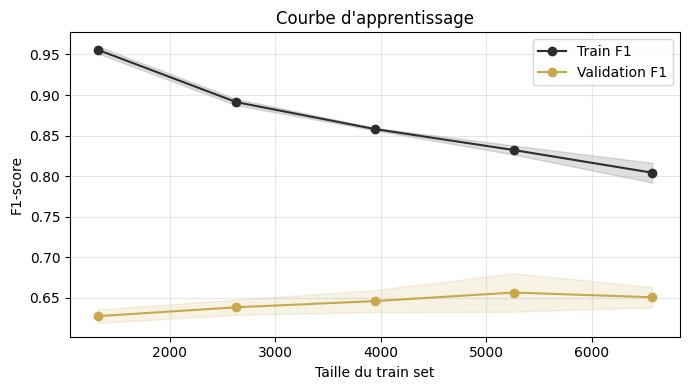


Gap train-val (learning curve, 3-fold) : 0.154
Gap train-test (holdout, cellule 7)    : 0.129


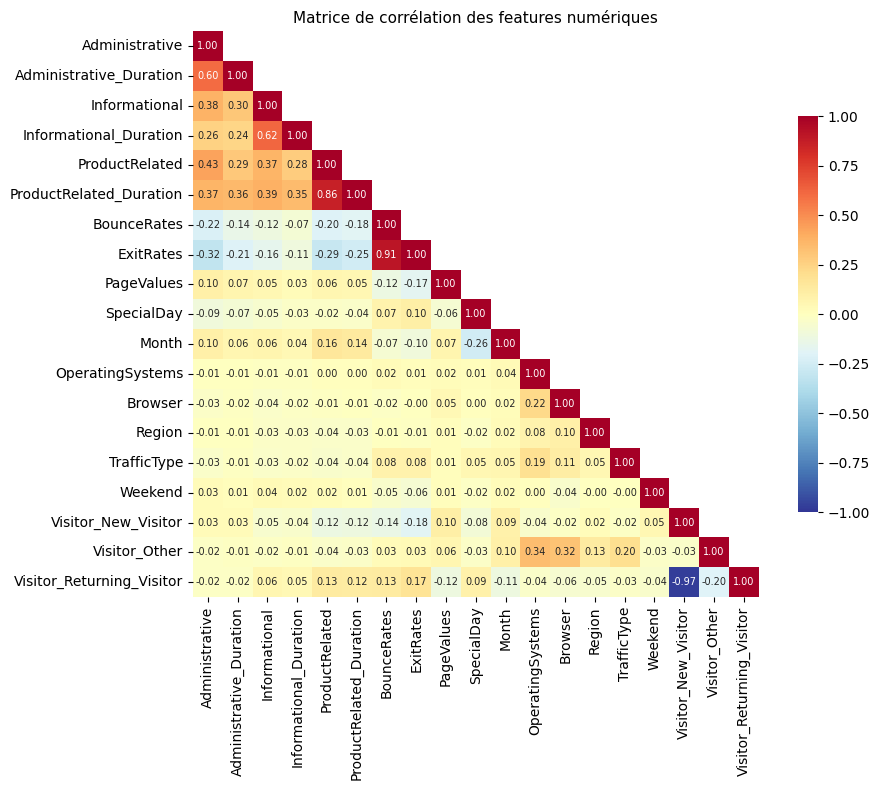


Features les plus corrélées (|r|) avec Month :
SpecialDay                   0.256901
ProductRelated               0.156022
ProductRelated_Duration      0.137520
Visitor_Returning_Visitor    0.112058
Visitor_Other                0.098687
Name: Month, dtype: float64

→ Corrélation maximale ≈ 0.26 : modérée.


In [11]:
# ── 9.5 : Performance par mois (filtre fiabilité) ────────────────────────────
MIN_POSITIVES = 10

inv_month_map = {v: k for k, v in month_map.items()}
test_months = X_test["Month"].map(inv_month_map)

per_month_perf = []
for month in [m for m in month_order if m in test_months.values]:
    mask = (test_months == month)
    n_pos = int(y_test[mask].sum())
    per_month_perf.append({
        "Month": month,
        "n_sessions": int(mask.sum()),
        "n_achats_reels": n_pos,
        "taux_achat_reel": float(y_test[mask].mean()),
        "f1": f1_score(y_test[mask], y_pred[mask], zero_division=0) if n_pos else np.nan,
        "recall": recall_score(y_test[mask], y_pred[mask], zero_division=0) if n_pos else np.nan,
        "precision": precision_score(y_test[mask], y_pred[mask], zero_division=0) if n_pos else np.nan,
        "reliable": n_pos >= MIN_POSITIVES,
    })

perf_full = pd.DataFrame(per_month_perf)
perf_df = perf_full[perf_full["reliable"]].drop(columns="reliable").reset_index(drop=True)
perf_dropped = perf_full[~perf_full["reliable"]]

print(f"Performance par mois — fiables (n_positifs ≥ {MIN_POSITIVES}) :")
print(perf_df.to_string(index=False))
if len(perf_dropped):
    print(f"\nMois écartés (n_positifs < {MIN_POSITIVES}, F1 non fiable) :")
    print(perf_dropped[["Month", "n_sessions", "n_achats_reels"]].to_string(index=False))

# Plot (mois fiables uniquement)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(perf_df["Month"], perf_df["taux_achat_reel"], color="#2d2d2d", alpha=0.4, label="Taux d'achat réel")
axes[0].bar(perf_df["Month"], perf_df["f1"], color="#C9A84C", alpha=0.9, label="F1-score du modèle")
axes[0].set_title("F1 vs taux d'achat réel, par mois")
axes[0].set_ylabel("Score"); axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(perf_df["Month"], perf_df["recall"], color="#8B6914", edgecolor="none")
axes[1].set_title("Recall (classe Achat) par mois")
axes[1].set_ylabel("Recall"); axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(perf_df["recall"].mean(), color="red", linestyle="--", alpha=0.5,
                label=f"Moyenne = {perf_df['recall'].mean():.2f}")
axes[1].legend(fontsize=8)
plt.suptitle(f"Performance par mois (n_positifs ≥ {MIN_POSITIVES})", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("report/fig05_perf_par_mois.png", dpi=150)
plt.show()

f1_min, f1_max = perf_df["f1"].min(), perf_df["f1"].max()
print(f"\nÉtendue F1 sur mois fiables : [{f1_min:.2f} ; {f1_max:.2f}]")
print("→ Hétérogénéité explicable par le taux d'achat réel qui varie d'un mois à l'autre,")
print("  pas par un shortcut.")


# ── 9.6 : Courbe d'apprentissage (n_jobs=1 pour déterminisme) ────────────────
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                subsample=0.8, random_state=RANDOM_STATE),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="f1",
    n_jobs=1,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#2d2d2d", label="Train F1")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#2d2d2d")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="#C9A84C", label="Validation F1")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#C9A84C")
ax.set_xlabel("Taille du train set"); ax.set_ylabel("F1-score")
ax.set_title("Courbe d'apprentissage"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("report/fig06_learning_curve.png", dpi=150)
plt.show()

train_val_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"\nGap train-val (learning curve, 3-fold) : {train_val_gap:.3f}")
print(f"Gap train-test (holdout, cellule 7)    : {holdout_gap:.3f}")


# ── 9.7 : Matrice de corrélation ─────────────────────────────────────────────
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = X[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matrice de corrélation des features numériques", fontsize=11)
plt.tight_layout()
plt.savefig("report/fig07_correlation_matrix.png", dpi=150)
plt.show()

month_corr = corr_matrix["Month"].drop("Month").abs().sort_values(ascending=False)
print("\nFeatures les plus corrélées (|r|) avec Month :")
print(month_corr.head(5))
print(f"\n→ Corrélation maximale ≈ {month_corr.iloc[0]:.2f} : modérée.")

## 10. Cross-validation — quantification de la variance

La cross-validation en 5 folds stratifiés fournit une **estimation de la variance** du score F1 due au choix du split. C'est une mesure critique pour la suite : tout gain de performance produit par une correction doit dépasser cette variance pour être considéré comme significatif.

L'écart-type obtenu ici constitue le **seuil de bruit** auquel comparer les améliorations du notebook 02.

In [12]:
# ── CELLULE 10 : Cross-validation pour estimer la variance ──────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_f1 = cross_val_score(gbm, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
cv_auc = cross_val_score(gbm, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
cv_recall = cross_val_score(gbm, X_train, y_train, cv=cv, scoring="recall", n_jobs=1)

print("Cross-validation 5-fold stratifiée — sur X_train uniquement :")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"\nHoldout F1 (cellule 7) : {test_f1:.4f}")
print(f"CV F1 (train)          : {cv_f1.mean():.4f}")
print(f"→ Écart |holdout − CV| = {abs(test_f1 - cv_f1.mean()):.4f}")
 

Cross-validation 5-fold stratifiée — sur X_train uniquement :
  F1     : 0.6535 ± 0.0184
  ROC-AUC: 0.9325 ± 0.0034
  Recall : 0.5957 ± 0.0216

Holdout F1 (cellule 7) : 0.6447
CV F1 (train)          : 0.6535
→ Écart |holdout − CV| = 0.0088


## 11. Sauvegarde des métriques de référence

Les métriques du modèle de référence sont sérialisées au format JSON. Elles seront rechargées dans le notebook 02 pour la comparaison **avant / après correction**.


In [13]:
# ── CELLULE 11 : Résumé des métriques de référence (à sauvegarder) ──────────
reference_metrics = {
    "model": "GBM_reference_standard_split",
    "accuracy": float((y_pred == y_test).mean()),
    "f1_purchase_train": float(train_f1),
    "f1_purchase_test": float(test_f1),
    "holdout_gap_f1": float(holdout_gap),
    "recall_purchase": float(recall_score(y_test, y_pred)),
    "precision_purchase": float(precision_score(y_test, y_pred)),
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
    "cv_f1_mean_on_train": float(cv_f1.mean()),
    "cv_f1_std_on_train": float(cv_f1.std()),
    "naive_baseline_accuracy": float(naive_acc),
    "naive_baseline_f1": float(naive_f1),
    "month_importance": float(month_imp),
    "pagevalues_importance": float(page_imp),
}

print("\n=== MÉTRIQUES DE RÉFÉRENCE ===")
for k, v in reference_metrics.items():
    print(f"  {k:<28} : {v:.4f}" if isinstance(v, float) else f"  {k:<28} : {v}")

import json
with open("report/reference_metrics.json", "w") as f:
    json.dump(reference_metrics, f, indent=2)
print("\n→ Sauvegardé dans report/reference_metrics.json")
 


=== MÉTRIQUES DE RÉFÉRENCE ===
  model                        : GBM_reference_standard_split
  accuracy                     : 0.8994
  f1_purchase_train            : 0.7737
  f1_purchase_test             : 0.6447
  holdout_gap_f1               : 0.1290
  recall_purchase              : 0.5890
  precision_purchase           : 0.7120
  roc_auc                      : 0.9267
  cv_f1_mean_on_train          : 0.6535
  cv_f1_std_on_train           : 0.0184
  naive_baseline_accuracy      : 0.8451
  naive_baseline_f1            : 0.0000
  month_importance             : 0.0542
  pagevalues_importance        : 0.6685

→ Sauvegardé dans report/reference_metrics.json


## 12. Synthèse des symptômes

| Symptôme | Mesure observée | Interprétation |
|---|---|---|
| Class imbalance | ~84.5 % non-achat / ~15.5 % achat | Métriques F1 / recall obligatoires |
| Baseline naïf (always-0) | accuracy = 0.845, F1_achat = 0 | Ancrage : tout F1 > 0 est un gain net |
| Hétérogénéité saisonnière | Conv. Nov ≈ 25 %, Mar ≈ 12 %, Feb ≈ 2 % | Variation forte du taux d'achat |
| F1 par mois (n_pos ≥ 10) | F1 ∈ [0.48 ; 0.77] | Amplitude ~0.25, corrélée au taux d'achat réel |
| Importance(`Month`) | ~5.4 % (vs `PageValues` ~67 %) | `Month` n'est PAS un shortcut dominant |
| Corrélation Month ↔ autres | max \|r\| ≈ 0.26 (SpecialDay) | Information temporelle relativement indépendante |
| F1 train / test | ~0.77 / ~0.64 | Gap ≈ 0.13 — zone intermédiaire (overfitting modéré) |
| Variance CV (sur train) | F1 = 0.65 ± 0.02 | Modèle stable, seuil de bruit ≈ 0.02 |

### Conclusion — diagnostic révisé

Les preuves rassemblées **ne soutiennent pas** une lecture mono-causale en termes d'overfitting massif ou de shortcut saisonnier :

1. **Failure mode dominant : class imbalance.** Recall sur la classe Achat ~0.59 — la majeure partie des erreurs vient de l'asymétrie, pas d'un défaut de capacité.
2. **Failure mode secondaire : overfitting modéré** (gap ≈ 0.13). Présent mais limité — CV faible variance et cohérence holdout/CV (écart < 1 σ) montrent que le modèle généralise correctement.
3. **Hypothèse de shortcut `Month` : réfutée.** Importance ≈ 5 %, ratio PageValues/Month ≈ 12×, corrélation modérée avec les autres features.

Le notebook 02 traitera l'**overfitting modéré comme failure mode étudié** (consigne) en restant honnête sur sa contribution relative : marge de progression bornée par σ_CV ≈ 0.02 et par le plafond imposé par l'imbalance.

**Suite** : `02_experiment.ipynb` — hypothèse falsifiable, courbes de validation, correction par régularisation, étude de sensibilité à l'encodage de `Month`.